# Click Detection Event Visualization

This notebook processes click detection results stored in CSV files. These files are organized into folders, each representing individual recording days. All folders containing CSV files must be located within the same parent directory. Each CSV file corresponds to detections computed from audio files recorded sequentially during that day.

## Processing Steps:

1. **Load CSV files**:
   - For each recording day (each folder), load the CSV files containing detected click events.
   - CSV files must contain columns for timestamps, high-intensity click events (`high_click_events`), and low-intensity click events (`low_click_events`).

2. **Aggregate data**:
   - Compute the number of detected high and low clicks per defined time window (e.g., per second).

2. **Visualization**:
   - **Time Series Plot**: Visualize the temporal dynamics of high-intensity click detections per second over the recording duration.
   - **Heatmap Visualization**:
     - Each heatmap row represents click counts per second within a minute, and each column represents consecutive minutes throughout the recording.
     - Columns visualize the evolution of event occurrences over time.

These visualizations aim to offer insights into the dynamics and patterns of acoustic click events across time.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
from matplotlib import rc

import librosa
from librosa.feature import melspectrogram
from scipy.signal import spectrogram, filtfilt, ShortTimeFFT, stft, windows
import soundfile as sf

from pathlib import Path
import os

import core.signal_processing as sp
from plot_setup import configure_plots, plot_spectrogram
_ = configure_plots()

from datetime import datetime, timedelta

## Load Sample CSV

We will start by visualizing click detections from a sample CSV file. This initial visualization will help us gain insights into the structure and organization of the data contained within these CSVs, which will be loaded into a pandas DataFrame.

Initially, we will visualize the occurrences of detected clicks to analyze their frequency and temporal distribution, overlaying this information with the plotted acoustic signal and spectrogram.

Subsequently, we will proceed with more elaborate visualizations, such as plotting temporal series of click events over each recording day and creating heatmaps that illustrate the occurrence dynamics of high and low click events throughout time.

In [2]:
## Load and plot sample audio

path = './data/wav_files/'

filename = 'AMAR170.20240518T064445Z.wav'

file_path = path + filename

# Get audio file information to extract the sample rate
info = sf.info(file_path, verbose=False)
fs = info.samplerate

print(f'Sample Rate: {fs/1000} kHz')


# Define the path to the directory containing the sample CSV file
path2csv = './data/detections'

# Define the specific CSV file name to load
csvname = 'AMAR170.20240518T064445Z.csv'

# Read the CSV file into a Pandas DataFrame
df_sample = pd.read_csv(f"{path2csv}/{csvname}")

# Display the first few rows of the DataFrame for initial inspection
df_sample.sum()

Sample Rate: 128.0 kHz


time_sec             180000000.0
high_click_events         1136.0
low_click_events          1153.0
dtype: float64

In [3]:
def parse_csv_start_time(csv_filename: str):
    """
    Extrai a data/hora de um nome no formato:
    AMAR170.20240518T064445Z.csv

    Retorna:
        datetime ou None
    """
    parts = csv_filename.split('.')
    if len(parts) < 3:
        return None

    timestamp_str = parts[1]  # '20240518T064445Z'

    try:
        return datetime.strptime(timestamp_str, "%Y%m%dT%H%M%SZ")
    except ValueError:
        return None


In [4]:
dt = parse_csv_start_time(csvname)
print(dt)

2024-05-18 06:44:45


In [5]:
start_time = 12    # Start time in seconds
duration = 15  # Duration in seconds

# Calculate the starting sample and the number of samples to read
start_sample = int(start_time * fs)
num_samples = int(duration * fs)


# filename = '5995.240602151600.wav'
# path = '../data/wav-files/2024-06-02/'

path = './data/wav_files/'
filename = 'AMAR170.20240518T064445Z.wav'

file_path = path + filename

signal, _ = sf.read(file_path, start=start_sample, frames=num_samples, always_2d=True)

x = signal[:,0]
t = np.arange(num_samples)/fs

# Compute spectrogram
time_resolution = 0.005
W = int(time_resolution * fs)
nfft = W
# ff, tt, Sxx = spectrogram(x, fs=fs, nperseg=W, noverlap=0, nfft=nfft)

# Define the Hann window as a vector
window = windows.hann(W, sym=False)

# Compute STFT
stft_transform = ShortTimeFFT(mfft=nfft, hop=W,  win=window, fft_mode='onesided', fs  = fs, scale_to='magnitude')
STFT = stft_transform.stft(x, p0=0, p1=len(x)//W, k_offset=0)#stft_transform.stft(x)
Sxx = np.abs(STFT)

# One-sided Frequency Vector
freqs_onesided = np.linspace(0,fs/2,nfft//2 + 1)

# Compute time vector (aligned with STFT frames)
num_frames = STFT.shape[1]  # Number of time frames
tt = np.arange(num_frames) * (W / fs)

print(f'Sxx shape: {STFT.shape}. f vector len: {len(freqs_onesided)}. nfft/2+1 = {nfft//2+1}')

Sxx shape: (321, 3000). f vector len: 321. nfft/2+1 = 321


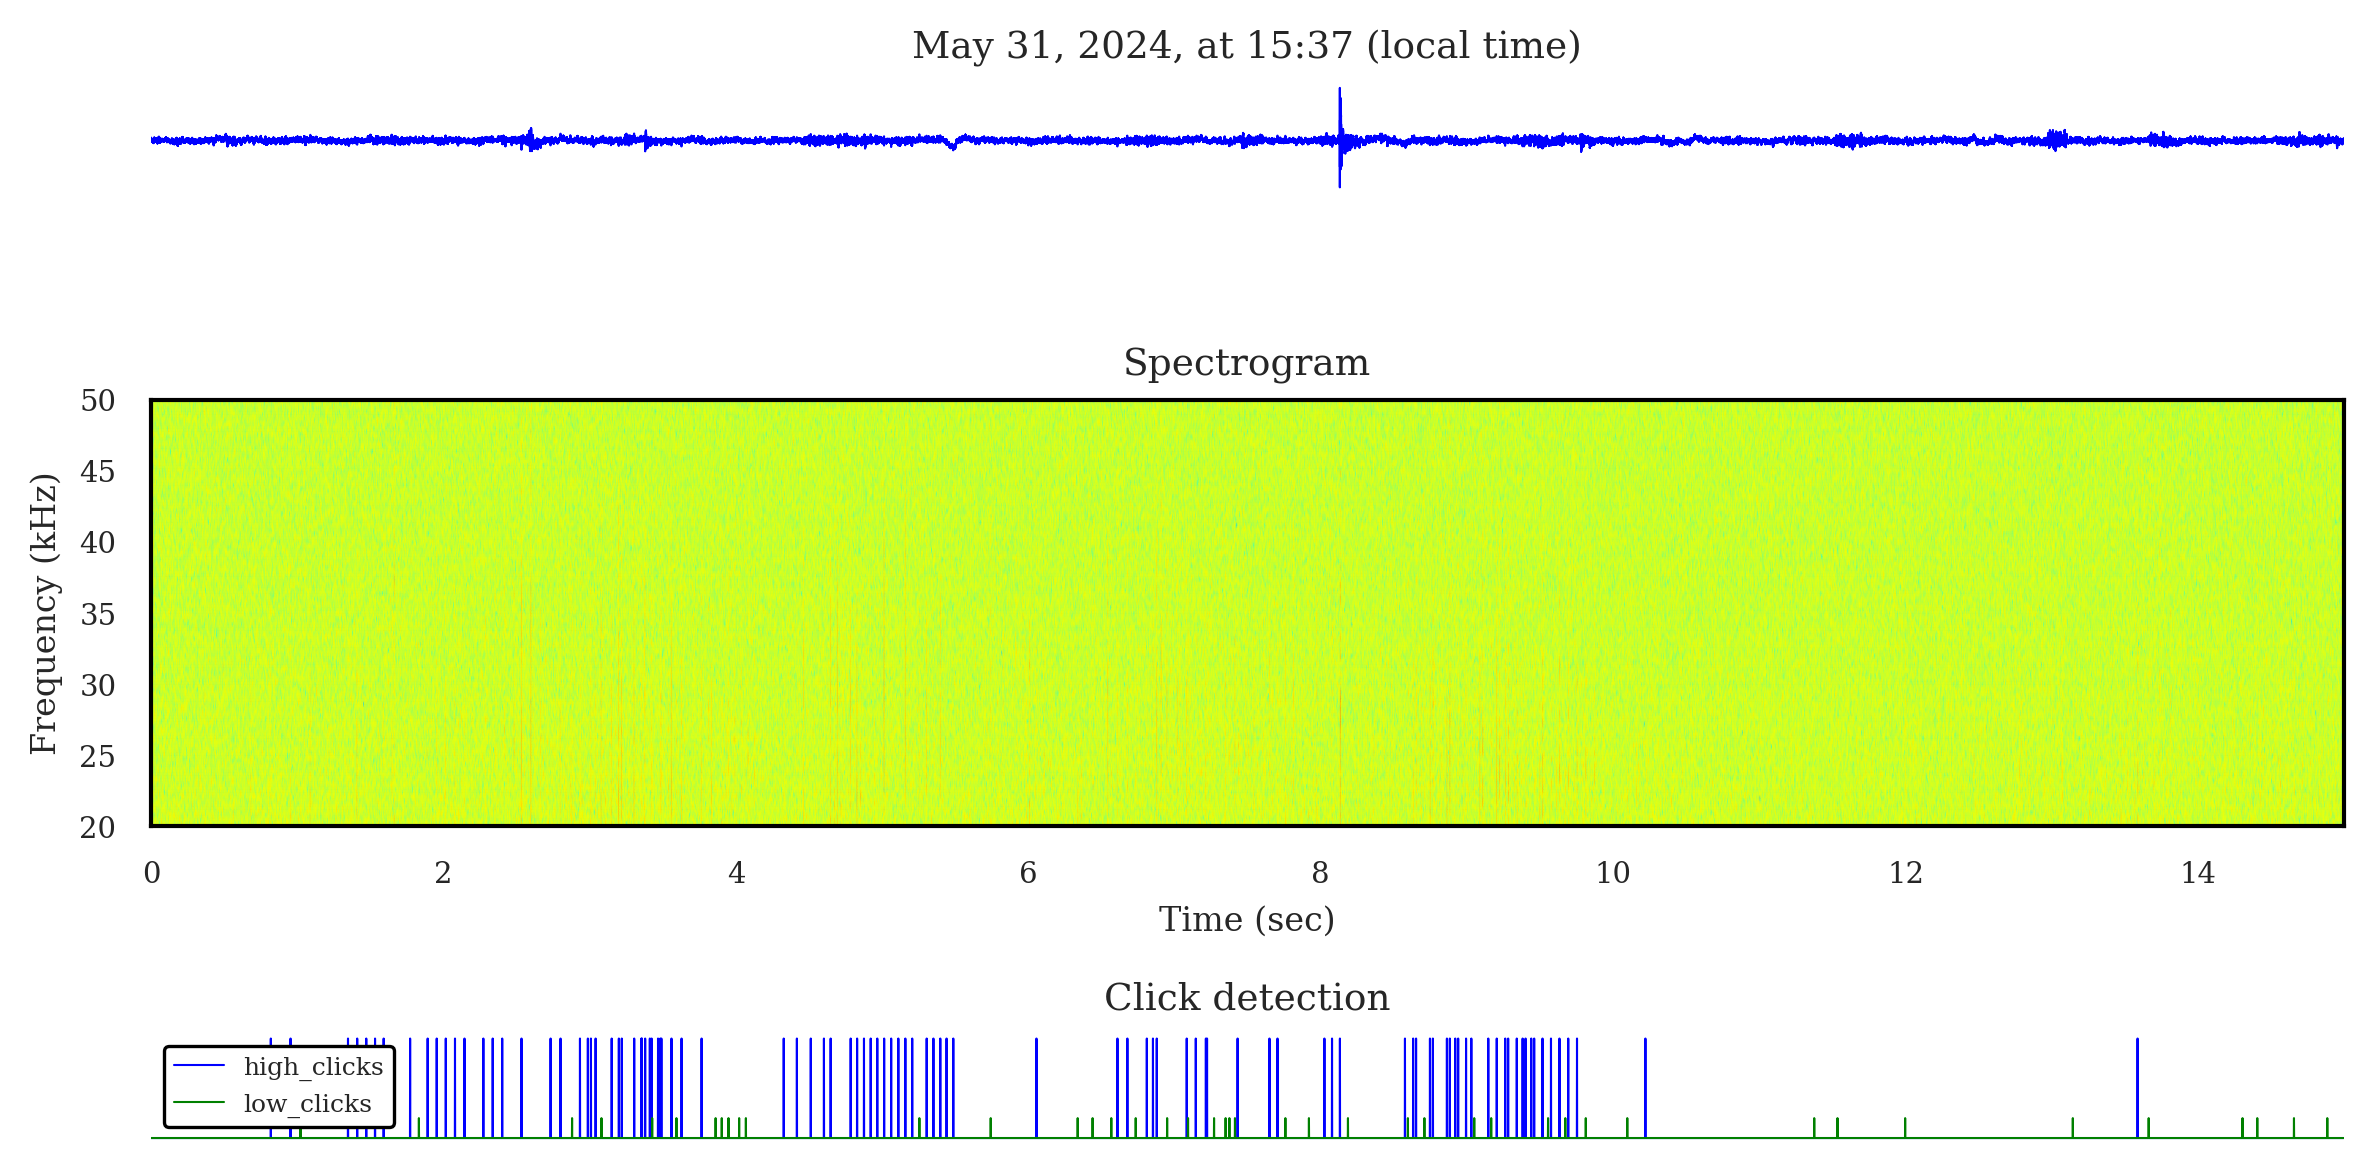

In [6]:
# Plot time istants of the click occrurence

fig = plt.figure(figsize=(8, 4))
ax1 = plt.subplot2grid((4, 1), (0, 0))
ax2 = plt.subplot2grid((4, 1), (1, 0), rowspan=2)
ax3 = plt.subplot2grid((4, 1), (3, 0), rowspan=1)

ax1.plot(t, x, color='b',linewidth=0.5, label = 'signal segment')
ax1.set_xlim(t[0], t[-1])
#ax1.legend(loc='upper left', fontsize = 6)
ax1.axis('off')
# title_str = f"File: {filename}, Start: {start_time:.0f}s, Duration: {duration:.0f}s"
title_str = 'May 31, 2024, at 15:37 (local time)'
ax1.set_title(title_str)

plot_spectrogram('Spectrogram', tt, freqs_onesided, Sxx, 'jet', ax2,  Scale = True, clim=False,fmin=20 , fmax= 50)

ax3.plot(df_sample['time_sec'],df_sample['high_click_events'], linewidth = 0.5, color = 'blue', label = 'high_clicks')
ax3.plot(df_sample['time_sec'],df_sample['low_click_events']*0.2, linewidth = 0.5, color = 'green', label = 'low_clicks')
ax3.set_xlim((start_time,start_time+duration))
ax3.set_xlabel('time (s)')

ax3.set_ylabel('Click occurrence')
ax3.axis('off')
ax3.set_title('Click detection')
ax3.legend(loc="upper left")

# Define the path and filename for saving the figure
save_path = '../Results/'

# Ensure the directory exists, if not, create it
if not os.path.exists(save_path):
    os.makedirs(save_path)

# Adjust layout and save the figure
fig.tight_layout()
# FigName = f'Globicephala_SampleSound_{duration}s.png'
FigName = f'Globicephala_SampleSound_2024-05-31_15-37-46_15s.png'
plt.savefig(os.path.join(save_path, FigName))  # Assuming save_path is defined
plt.show()


## Time Series Plot

Next, we will visualize the temporal dynamics of click detections. To achieve this, we will aggregate event occurrences within predefined time segments (e.g., 1 second).

For each CSV file that is loaded, we will use the **"time_sec"** column to determine the duration of the respective WAV file. This step is necessary not only to concatenate and analyze aggregated values but also to create a time vector in **datetime format** (or an equivalent representation) for accurately plotting the time series.

### **File Naming and Time Alignment Considerations**  

The CSV files follow a structured naming convention that includes the timestamp corresponding to the **start time of the audio recording**. The format is:

```
XXXX.YYMMDDHHMMSS.csv
```

To properly align the time series, we need to extract this timestamp from the filename and combine it with the **"time_sec"** column from the DataFrame. This will allow us to generate an absolute time vector at the defined resolution (e.g., 1 second), ensuring the detected events are correctly positioned in time.

### **Handling Incomplete Recordings**  

It is also essential to account for interrupted recordings, where the corresponding WAV file may not have been fully recorded. Each WAV file is expected to have a 2-minute duration (120 seconds). However, due to the 1 ms frame resolution used for computing click detection events, the expected final value in the "time_sec" column should be 119.999 seconds (not 120 seconds).

In some cases, a CSV file may contain an even shorter duration (e.g., 117.999 seconds instead of 119.999 for a 120-second recording). This suggests that the recording process was interrupted before completion. To ensure consistency in time-series visualization, we must account for these missing data points.

When aggregating the detected clicks into a coarser time resolution (e.g., 1-second intervals), any missing frames should be represented appropriately. For instance, if a recording ends prematurely, we should insert NaN values in the aggregated time series for the corresponding missing seconds. If a CSV file contains only 117.999 seconds of data, we should append two NaN values to the aggregated click detection series at the 1-second resolution to maintain the expected time alignment.

In [ ]:
def aggregate_csv_data(df, csv_filename: str, bin_size=1.0, full_duration=120.0):
    """
    Aggregates click events from a DataFrame into a 120-element array (1..120).
    For incomplete files, trailing bins are filled with NaN.

    Args:
      df (pd.DataFrame): must contain columns ['time_sec', 'high_click_events', 'low_click_events'].
      csv_filename (str): used to parse the base datetime (yymmddHHMMSS).
      bin_size (float): the bin width in seconds (default 1.0).
      full_duration (float): total expected duration in seconds (default 120.0).

    Returns:
      second_bins -> array [1,2,...,120]
      high_clicks -> length-120 float array, sum of high-click events per bin (NaN after incomplete portion)
      low_clicks  -> length-120 float array, sum of low-click events per bin
      base_dt     -> datetime parsed from csv_filename (or None)
    """
    time_arr = df["time_sec"].to_numpy()
    high_click_arr = df["high_click_events"].to_numpy()
    low_click_arr  = df["low_click_events"].to_numpy()

    # Bin edges from 0..120
    bin_edges = np.arange(0, full_duration + bin_size, bin_size)  # 0..120 in steps of 1

    # Clamp times to [0..120]
    time_arr_clamped = np.clip(time_arr, 0, full_duration)

    # Weighted histograms
    high_hist, _ = np.histogram(time_arr_clamped, bins=bin_edges, weights=high_click_arr)
    low_hist,  _ = np.histogram(time_arr_clamped, bins=bin_edges, weights=low_click_arr)

    # Keep them as float arrays so we can assign np.nan
    high_hist = high_hist.astype(float)
    low_hist  = low_hist.astype(float)

    # bin indices => second_bins = [1..120]
    second_bins = np.arange(1, full_duration + 1)

    # Identify the maximum integer second recorded
    max_time = np.floor(time_arr.max()) if len(time_arr) > 0 else 0.0
    max_bin_index = int(max_time)  # e.g., 117 => means up to second 117 is known

    # Mark incomplete portion with np.nan
    # If the file ends at 117.999 => the last 2 bins (118..119) => np.nan
    high_hist[max_bin_index+1:] = np.nan
    low_hist[max_bin_index+1:]  = np.nan

    # parse CSV start datetime
    base_dt = parse_csv_start_time(csv_filename)

    return second_bins, high_hist, low_hist, base_dt


In [ ]:
second_bins, high_hist, low_hist, base_dt = aggregate_csv_data(df_sample, csvname)

fig,ax = plt.subplots(figsize = (4,2))

ax.plot(second_bins, high_hist, linewidth = 0.5,color = 'blue')
ax.plot(second_bins, low_hist, linewidth = 0.5,color = 'green')

fig.tight_layout()
plt.show()

In [ ]:
input_base_dir = Path("./data/detections")

# We'll store the final aggregated arrays in a dictionary keyed by day folder
daily_data = {}

# Loop over day folders
for folder in input_base_dir.glob("2024*"):
    day_name = folder.name
    print(f"Processing day folder: {day_name}")

    # We'll accumulate data for each CSV in this day
    # so we can combine them into one continuous array
    all_times = []        # list of np.ndarray (datetime64 or Python datetime objects)
    all_high = []         # list of np.ndarray
    all_low  = []         # list of np.ndarray

    # We'll also store each CSV's base_dt to do sorting if needed
    csv_records = []

    for csv_file in folder.glob("*.csv"):
        df_sample = pd.read_csv(csv_file)
        second_bins, high_arr, low_arr, base_dt = aggregate_csv_data(df_sample, csv_file.name)

        # If base_dt is valid, build an absolute time array:
        # For bin i in [1..120], time = base_dt + (i-1) seconds (since i=1 => offset=0)
        # We'll create a NumPy array of datetimes or keep them as Python objects
        if base_dt is not None:
            time_array = np.array([base_dt + timedelta(seconds=int(s)-1) for s in second_bins], dtype='object')
        else:
            # fallback => just store [NaN or None], or store an integer time reference
            time_array = np.array([None]*len(second_bins), dtype='object')

        # Append to the CSV records
        csv_records.append({
            'start_dt': base_dt,
            'time_array': time_array,
            'high_array': high_arr,
            'low_array':  low_arr
        })

    # If you want to sort by the start_dt to ensure chronological order:
    csv_records.sort(key=lambda rec: rec['start_dt'] or "")

    # Now we can concatenate them if we want a single time array for the entire day
    # We'll just do a big append in chronological order
    all_times = [rec['time_array'] for rec in csv_records]
    all_high  = [rec['high_array'] for rec in csv_records]
    all_low   = [rec['low_array']  for rec in csv_records]

    # Concatenate into one array
    day_times = np.concatenate(all_times)
    day_high  = np.concatenate(all_high)
    day_low   = np.concatenate(all_low)

    # Store final arrays in daily_data
    daily_data[day_name] = {
        'time': day_times,       # array of length (Nfiles * 120)
        'high': day_high,        # float array with possible NaNs
        'low':  day_low
    }

# Now daily_data has one big array per day with absolute datetimes in day_data[day_name]['time']
# and corresponding high/low click arrays. If any file is incomplete, trailing bins are NaN.


In [ ]:
# Assume daily_data is a dictionary with exactly 3 keys, one for each day
# daily_data[day_key] = {
#     'time': array of shape (N_total,)  (datetime or numeric),
#     'high': array of shape (N_total,)  (floats, may have NaN),
#     'low':  array of shape (N_total,)  (floats, may have NaN)
# }

fig, axs = plt.subplots(nrows=3, ncols=2, figsize=(8, 6),
                        sharex=True, sharey=True)

# Sort day_keys to get a consistent order (optional)
sorted_day_keys = sorted(daily_data.keys())

for i, day_key in enumerate(sorted_day_keys):
    # Retrieve data for this day
    # day_times = daily_data[day_key]['time']   # e.g. array of datetimes
    day_times = np.array([
        t.replace(year=1900, month=1, day=1)
        for t in daily_data[day_key]['time']
    ], dtype='datetime64[ns]')
    day_high  = daily_data[day_key]['high']
    day_low   = daily_data[day_key]['low']

    # Left column: High-click events in blue
    ax_high = axs[i, 0]
    ax_high.plot(day_times, day_high, color='blue', label='High Clicks', linewidth = 0.5)
    # Optionally add day label or text
    ax_high.set_title(f"{day_key} - High Clicks")
    ax_high.set_ylabel('Click detections (sec)')

    # Right column: Low-click events in green
    ax_low = axs[i, 1]
    ax_low.plot(day_times, day_low, color='green', label='Low Clicks', linewidth = 0.5)
    ax_low.set_title(f"{day_key} - Low Clicks")

    # Optional grid
    ax_high.grid(True, alpha=0.3)
    ax_low.grid(True, alpha=0.3)

    # If day_times is datetime, the x-axis will automatically format as dates/times
    # If numeric, you may want ax.set_xlabel("Seconds") or similar

# # If you want a common x-label or y-label, you can do:
# fig.text(0.5, 0.04, 'Time', ha='center')
# fig.text(0.04, 0.5, 'Clicks', va='center', rotation='vertical')

# Optional grid
ax_high.set_xlabel('Data time for current day')
ax_low.set_xlabel('Data time for current day')

# Adjust layout to avoid overlapping titles/labels
fig.tight_layout()
FigName = f'Globicephala_ClickDetection_datatime.png'
plt.savefig(os.path.join(save_path, FigName))  # Assuming save_path is defined
plt.show()


In [ ]:
fig, axs = plt.subplots(nrows=3, ncols=2, figsize=(8, 6),
                        sharex=False, sharey=True)

# Sort day_keys to get a consistent order (optional)
sorted_day_keys = sorted(daily_data.keys())

for i, day_key in enumerate(sorted_day_keys):
    # Retrieve data for this day
    # day_times = daily_data[day_key]['time']   # e.g. array of datetimes
    day_times = np.array([(t - daily_data[day_key]['time'][0]).total_seconds() 
                      for t in daily_data[day_key]['time']], dtype=float)/60
    day_high  = daily_data[day_key]['high']
    day_low   = daily_data[day_key]['low']

    # Left column: High-click events in blue
    ax_high = axs[i, 0]
    ax_high.plot(day_times, day_high, color='blue', label='High Clicks', linewidth = 0.5)
    # Optionally add day label or text
    ax_high.set_title(f"{day_key} - High Clicks")
    ax_high.set_ylabel(r'Click detections ($\times$ sec)')

    # Right column: Low-click events in green
    ax_low = axs[i, 1]
    ax_low.plot(day_times, day_low, color='green', label='Low Clicks', linewidth = 0.5)
    ax_low.set_title(f"{day_key} - Low Clicks")

    # Optional grid
    ax_high.grid(True, alpha=0.3)
    ax_low.grid(True, alpha=0.3)

    # If day_times is datetime, the x-axis will automatically format as dates/times
    # If numeric, you may want ax.set_xlabel("Seconds") or similar

# # If you want a common x-label or y-label, you can do:
# fig.text(0.5, 0.04, 'Time', ha='center')
# fig.text(0.04, 0.5, 'Clicks', va='center', rotation='vertical')

# Optional grid
ax_high.set_xlabel('Recording duration (min)')
ax_low.set_xlabel('Recording duration (min)')

# Adjust layout to avoid overlapping titles/labels
fig.tight_layout()
FigName = f'Globicephala_ClickDetection_time.png'
plt.savefig(os.path.join(save_path, FigName))  # Assuming save_path is defined
plt.show()

In [ ]:
fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(8, 6),
                        sharex=False, sharey=True)

# Sort day_keys to get a consistent order (optional)
sorted_day_keys = sorted(daily_data.keys())

for i, day_key in enumerate(sorted_day_keys):
    # Retrieve data for this day
    # day_times = daily_data[day_key]['time']   # e.g. array of datetimes
    day_times = np.array([(t - daily_data[day_key]['time'][0]).total_seconds() 
                      for t in daily_data[day_key]['time']], dtype=float)/60
    day_high  = daily_data[day_key]['high']
    day_low   = daily_data[day_key]['low']

    ax = axs[i]
    ax.plot(day_times, day_high, color='blue', label='High Clicks', linewidth = 0.5)
    # Optionally add day label or text
    ax.set_title(f"{day_key} - High Clicks")
    ax.set_ylabel(r'Click detections ($\times$ sec)')

    ax.plot(day_times, day_low, color='green', label='Low Clicks', linewidth = 0.5)
    ax.set_title(f"{day_key} - Low Clicks")

    # Optional grid
    ax.grid(True, alpha=0.3)

# Optional grid
ax.set_xlabel('Recording duration (min)')

# Adjust layout to avoid overlapping titles/labels
fig.tight_layout()
FigName = f'Globicephala_ClickDetectionMerged_time.png'
plt.savefig(os.path.join(save_path, FigName))  # Assuming save_path is defined
plt.show()

In [ ]:
# Suppose daily_data[day_key]['time'] is an array of Python datetime objects

fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(8, 6), sharex=False, sharey=True)

# Initialize dictionary to store aggregated minute-level data for each day
daily_minute_agg = {}

sorted_day_keys = sorted(daily_data.keys())

for i, day_key in enumerate(sorted_day_keys):
    # Retrieve data for this day
    # day_times is an array of datetime objects
    day_times_dt = daily_data[day_key]['time']  
    day_high = daily_data[day_key]['high']      
    day_low  = daily_data[day_key]['low']

    # 1) Convert the datetime array to a numeric array (seconds) 
    #    relative to the earliest timestamp
    if len(day_times_dt) == 0:
        # Handle empty data
        continue

    t0 = day_times_dt[0]  # earliest time
    day_times_sec = np.array([
        (t - t0).total_seconds() for t in day_times_dt
    ], dtype=float)

    # 2) Create a small DataFrame for grouping
    df_day = pd.DataFrame({
        'minute_index': np.floor(day_times_sec / 60).astype(int),
        'high': day_high,
        'low':  day_low
    })

    # 3) Group by integer minute and sum up the clicks in that minute
    df_agg = df_day.groupby('minute_index', as_index=False).sum()

    # 3.1) Save aggregated DataFrame to dictionary for later use
    daily_minute_agg[day_key] = df_agg

    # 4) Plot 
    ax = axs[i]
    ax.plot(df_agg['minute_index'], df_agg['high'], '-o', color='blue',
            markersize=1, linewidth=0.5, label='High Clicks')
    ax.plot(df_agg['minute_index'], df_agg['low'], '-o', color='green',
            markersize=1, linewidth=0.5, label='Low Clicks')

    ax.set_title(f"{day_key}: 1-minute Aggregated Detections")
    ax.set_ylabel("Click Counts")
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right')

# Only label x-axis on the bottom plot
axs[-1].set_xlabel("Time (minutes)")

fig.tight_layout()
FigName = "Globicephala_ClickDetection_perMinute.png"
# plt.savefig(os.path.join(save_path, FigName))
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import timedelta, datetime
import os

fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(8, 6), sharex=True, sharey=True)

sorted_day_keys = sorted(daily_data.keys())

for i, day_key in enumerate(sorted_day_keys):
    # 1) Retrieve arrays for this day
    day_times_original = daily_data[day_key]['time']  # array of Python datetimes
    day_high = daily_data[day_key]['high']
    day_low  = daily_data[day_key]['low']

    if len(day_times_original) == 0:
        continue  # skip if empty

    # 2) Strip each timestamp to 1900-01-01 (keeping only HH:MM:SS)
    #    We end up with a Python datetime object for the same day (1900-01-01).
    #    Then convert them to np.datetime64[ns].
    day_times_1900 = np.array([
        t.replace(year=1900, month=1, day=1)
        for t in day_times_original
    ], dtype='datetime64[ns]')

    # 3) Convert day_times_1900 to minutes from the earliest time-of-day in that array
    #    (the earliest might be e.g. 1900-01-01 08:00:00, so we subtract that from all).
    t0 = day_times_1900.min()  # earliest time in 1900
    # Calculate how many minutes each sample is from t0
    day_times_min = (day_times_1900 - t0) / np.timedelta64(1, 'm')  # float array

    # 4) Build a DataFrame for grouping by minute
    df_day = pd.DataFrame({
        'minute_index': np.floor(day_times_min).astype(int),
        'high': day_high,
        'low':  day_low
    })

    # 5) Group by integer minute (0, 1, 2, ...) and sum clicks
    df_agg = df_day.groupby('minute_index', as_index=False).sum()

    # 6) Reconstruct a new datetime for each binned minute
    #    time_of_day[i] = t0 + df_agg['minute_index'][i] minutes
    #    We'll keep them as np.datetime64 for easy plotting with Matplotlib
    bin_dt = np.array([
        t0 + np.timedelta64(int(m), 'm')
        for m in df_agg['minute_index']
    ], dtype='datetime64[ns]')

    # 7) Plot
    ax = axs[i]
    ax.plot(bin_dt, df_agg['high'], '-o', color='blue', markersize=1, linewidth=0.5, label='High Clicks')
    ax.plot(bin_dt, df_agg['low'],  '-o', color='green', markersize=1, linewidth=0.5, label='Low Clicks')

    ax.set_title(f"{day_key}: 1-minute Aggregated (Time of Day Only)")
    ax.set_ylabel("Click Counts")
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right')

    # Format x-axis as HH:MM
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

# Label x-axis only on bottom plot
axs[-1].set_xlabel("Time of Day (HH:MM)")

fig.tight_layout()

FigName = "Globicephala_ClickDetection_Minute_TimeOfDay.png"
plt.savefig(os.path.join(save_path, FigName))
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Let's assume:
# daily_data[day_key] = {
#    'time': array of shape (N_minutes,) – either 0..X or just indexes
#    'high': array of shape (N_minutes,) – minute-based aggregated high clicks
#    'low':  array of shape (N_minutes,) – minute-based aggregated low clicks
# }

# 1) Gather daily detection rates (means or sums)
day_list = sorted(daily_data.keys())
high_rates = []
low_rates = []

for day_key in day_list:
    day_high = daily_data[day_key]['high']  # e.g. shape (N,) for that day
    day_low  = daily_data[day_key]['low']
    # Remove NaNs in case some bins are missing (incomplete file)
    valid_high = day_high[~np.isnan(day_high)]
    valid_low  = day_low[~np.isnan(day_low)]
    # Example: compute mean detection per minute
    if len(valid_high) == 0:
        high_rates.append(0.0)
    else:
        high_rates.append(np.mean(valid_high))
    if len(valid_low) == 0:
        low_rates.append(0.0)
    else:
        low_rates.append(np.mean(valid_low))

# 2) Create grouped bar plot
fig, ax = plt.subplots(figsize=(8, 3))

x = np.arange(len(day_list))  # numeric positions for each day
bar_width = 0.15

# Plot bars for High
rects_high = ax.bar(x - bar_width/2, high_rates, bar_width,
                    label='High Click Rate', color='blue')

# Plot bars for Low
rects_low = ax.bar(x + bar_width/2, low_rates, bar_width,
                   label='Low Click Rate', color='green')

# 3) Format x-axis
ax.set_xticks(x + bar_width/2)
ax.set_xticklabels(day_list, rotation=0, ha='right')

ax.set_ylabel('Mean Clicks/Minute')  # or sum, depending on your approach
ax.set_title('High vs. Low Click Detection Rates by Day')
ax.legend()

ax.grid(axis='y', alpha=0.3)  # optional horizontal grid
fig.tight_layout()

# 4) Save figure if desired
FigName = "Globicephala_ClickDetection_BarPlot.png"
plt.savefig(os.path.join(save_path, FigName))
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
import os

# ---- Assume `daily_data` and `daily_minute_agg` already exist in your environment ----

# Compute mean high/low clicks per day for Code 2 (barplot logic)
day_list = sorted(daily_minute_agg.keys())
high_rates = []
low_rates = []

for day_key in day_list:
    df_agg = daily_minute_agg[day_key]

    valid_high = df_agg['high'].dropna()
    valid_low = df_agg['low'].dropna()

    high_rate = valid_high.mean() if not valid_high.empty else 0.0
    low_rate = valid_low.mean() if not valid_low.empty else 0.0

    high_rates.append(high_rate)
    low_rates.append(low_rate)

# Prepare the figure layout
fig = plt.figure(figsize=(10, 4))
# gs = gridspec.GridSpec(nrows=1, ncols=4, width_ratios=[1.0, 1.0, 1.0, 0.8], wspace=0.5)

ax1 = plt.subplot2grid((3, 3), (0, 0), colspan=2)
ax2 = plt.subplot2grid((3, 3), (1, 0), colspan=2)
ax3 = plt.subplot2grid((3, 3), (2, 0), colspan=2)
ax4 = plt.subplot2grid((3, 3), (0, 2), rowspan=3)

gs = [ax1, ax2 , ax3, ax4]

# -----------------------------
# LEFT: 3 time series subplots
# -----------------------------
sorted_day_keys = sorted(daily_data.keys())

for i, day_key in enumerate(sorted_day_keys):
    ax = fig.add_subplot(gs[i])
    
    day_times_dt = daily_data[day_key]['time']
    day_high = daily_data[day_key]['high']
    day_low  = daily_data[day_key]['low']

    if len(day_times_dt) == 0:
        continue

    # Convert datetime to seconds relative to start of the day
    t0 = day_times_dt[0]
    day_times_sec = np.array([(t - t0).total_seconds() for t in day_times_dt])

    # Create minute aggregation
    df_day = pd.DataFrame({
        'minute_index': np.floor(day_times_sec / 60).astype(int),
        'high': day_high,
        'low':  day_low
    })

    df_agg = df_day.groupby('minute_index', as_index=False).sum()
    daily_minute_agg[day_key] = df_agg  # Save back in case not done yet

    # Plot
    ax.plot(df_agg['minute_index'], df_agg['high'], '-o', color='blue',
            markersize=1, linewidth=0.5, label='High Clicks')
    ax.plot(df_agg['minute_index'], df_agg['low'], '-o', color='green',
            markersize=1, linewidth=0.5, label='Low Clicks')

    ax.set_title(f"{day_key}", fontsize=10)
    ax.set_ylabel("Click Counts")
    ax.grid(True, alpha=0.3)

    if i == 1:
        ax.legend(fontsize=8)

    if i == 2:
        ax.set_xlabel("Time (minutes)")

# ---------------------------------------------------------
# RIGHT: Horizontal grouped bar plot for daily click rates
# ---------------------------------------------------------
ax_bar = fig.add_subplot(gs[3])

y = np.arange(len(day_list))[::-1]
bar_height = 0.35

ax_bar.barh(y - bar_height/2, high_rates, height=bar_height,
            label='High', color='blue')
ax_bar.barh(y + bar_height/2, low_rates, height=bar_height,
            label='Low', color='green')

ax_bar.set_yticks(y)
ax_bar.set_yticklabels(day_list, fontsize=9)
ax_bar.set_xlabel("Mean Clicks/Minute")
ax_bar.set_title("Daily Click Rate", fontsize=10)
ax_bar.legend(loc='lower right', fontsize=6)
ax_bar.grid(axis='x', alpha=0.3)

# -----------------
# Final adjustments
# -----------------
# fig.suptitle("Globicephala Click Detection: Per-Minute Activity and Daily Rates", fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.95])
# fig.tight_layout()

# Save figure
save_path = "../Results"
FigName = "Combined_ClickDetection_Activity_and_Barplot.png"
plt.savefig(os.path.join(save_path, FigName), dpi=300)
plt.show()



### **Loading and Concatenating Daily Sxx Frequency Bands (Sxx_fbands)**

In this section of the notebook, we will load **STFT matrices aggregated into frequency bands (Sxx_fbands)**, previously computed and saved in `.npz` format for each processed WAV file.  

Our goal is to **concatenate these matrices sequentially** to generate a **single continuous matrix representing the spectral content for an entire day** — referred to as `daily_Sxx_fbands`. This concatenated data will allow us to visualize **long-term spectral dynamics** and relate them to **event detections** such as clicks. Each day's data will be stored as an instance of a dictionary, indexed by date.

#### **Handling Incomplete Segments**
It is important to note that **each individual Sxx_fbands matrix** corresponds to a mid-term window (e.g., 2 minutes), and it is expected to have a **fixed number of frames** (for instance, 120 frames, if computed as 1-second resolution for 2 minutes).  
However, since some recordings may have been **interrupted or incomplete**, their corresponding Sxx matrices may be shorter than expected. To ensure that **time alignment and concatenation** proceed without errors, **incomplete matrices will be padded with NaNs** up to the expected length.  
This approach is consistent with the strategy we previously applied to **click count aggregations**, where missing time bins were also marked with NaN to preserve temporal structure.

#### **Final Output Structure**
At the end of this step, we will obtain:
- **A dictionary** where each key corresponds to a day (folder name), and each value contains:
  - The concatenated `daily_Sxx_fbands` matrix for that day.
  - The corresponding list of frequency band centers (`freqs_fband`).
  - The concatenated time vector (`time_fr`), aligned with the matrix.

#### **Summary of the Process**
- Load individual `.npz` files containing Sxx_fbands, frequency bands, and time frames.
- Check and pad each Sxx matrix if its time dimension is shorter than expected.
- Concatenate all matrices from the same day into a single `daily_Sxx_fbands`.
- Store and organize these daily matrices in a dictionary for visualization and analysis.

In [ ]:
# Path to input directory containing folders (each for a recording day)
input_base_dir = Path("../data/mel_Sxx_fband")

# Dictionary to store final aggregated Sxx_fband arrays, keyed by day folder
daily_Sxx_fbands = {}

# Fixed number of frequency bands (as per previous processing)
num_fbands = 80 #300 when load from linear frequency bands, but for mel_Sxx_fband we use 40 points

# Initialize a shared variable for frequency bands, to be loaded from first file encountered
freq_fbands = None

short_term_sec = 0.1
# The duration of individual wav fails it is expected to be 2 min (120 sec), thus based on that we can compute number of expected frames for each file
num_frames_xfile = np.ceil(120/short_term_sec).astype(int)

# --- Loop over day folders ---
for folder in input_base_dir.glob("2024*"):
    day_name = folder.name
    # print(f"Processing day folder: {day_name}")

    # Gather list of .npz files for this day and count them
    npz_files = list(folder.glob("*.npz"))
    num_files = len(npz_files)

    if num_files == 0:
        print(f"Warning: No files found for day {day_name}")
        continue  # Skip to next folder if no files present

    # Pre-allocate NaN-filled matrix to concatenate Sxx_fband for all files in this day
    total_frames = int(num_files * num_frames_xfile)  # Eaxmple, Expecting num_frames_xfile frames (2 min) per file
    Sxx_fbands_concatenated = np.full((num_fbands, total_frames), np.nan, dtype=float)  # Pre-fill with NaN

    # Placeholder for time vector (to be collected from daily_data previously stored)
    # Assuming daily_data[day_name]['day_times'] is loaded elsewhere with correct length
    day_times = daily_data[day_name]['time']  # You should ensure 'daily_data' is available and aligned

    # --- Process and concatenate each npz file ---
    for idx, numpy_file in enumerate(sorted(npz_files)):  # Sorted to keep chronological order
        data = np.load(numpy_file)

        # Load Sxx_fband matrix
        current_Sxx = data['Sxx_fband']

        # Store frequency bands only once (from first file)
        if freq_fbands is None:
            freq_fbands = data['freqs_fband']

        # Handle incomplete files (e.g., <num_frames_xfile frames)
        frames_in_file = current_Sxx.shape[1]  # May be less than num_frames_xfile
        temp_Sxx_fband = np.full((num_fbands, num_frames_xfile), np.nan, dtype=float)  # Temporary padded array
        temp_Sxx_fband[:, :frames_in_file] = current_Sxx  # Fill with available data

        # Compute slice indices for placing into concatenated array
        start_idx = idx * num_frames_xfile
        end_idx = start_idx + num_frames_xfile
        Sxx_fbands_concatenated[:, start_idx:end_idx] = temp_Sxx_fband
    
    vmin = np.percentile(np.log10(Sxx_fbands_concatenated), 25)
    vmax = np.percentile(np.log10(Sxx_fbands_concatenated), 99.99)
    # --- Store concatenated results if time vector matches expected length ---
    if (num_files * num_frames_xfile) == Sxx_fbands_concatenated.shape[1]:
        print(f"Processed day folder '{day_name}' successfully: {Sxx_fbands_concatenated.shape[1]} time frames aligned.")
        daily_Sxx_fbands[day_name] = {
            # 'time': day_times,                    # Time vector of length (num_files * num_frames_xfile)
            'Sxx_fband': Sxx_fbands_concatenated, # Concatenated matrix [num_fbands, total_frames]
            'freqs_fband': freq_fbands            # Frequency bands (shared across all files)
        }

        print(f'clim values, vmin:{vmin}, vmax:{vmax}')
    else:
        print(f"Warning: Time dimension mismatch in folder '{day_name}'. "
              f"Expected {Sxx_fbands_concatenated.shape[1]}, got {len(day_times)}.")


In [ ]:
# Now spectrograms and click will be visualized 

fig = plt.figure(figsize=(15,6))

days = sorted(list(input_base_dir.glob("2024*")))

for iday,day in enumerate(days):
    ax1 = plt.subplot2grid((4, 3), (0, iday))
    ax2 = plt.subplot2grid((4, 3), (1, iday), rowspan=2)
    ax3 = plt.subplot2grid((4, 3), (3, iday), rowspan=1)
    
    day_name = day.name
    # Time, high and low click counts for current day
    day_times = daily_data[day_name]['time']
    high_click = daily_data[day_name]['high']
    low_click = daily_data[day_name]['low']

    Sxx_fband = daily_Sxx_fbands[day_name]['Sxx_fband']

    # Replace NaN values with the computed mean
    # Sxx_fband[np.isnan(Sxx_fband)] = np.nanmean(Sxx_fband)

    # plot high click for the current day
    ax1.plot(day_times, high_click, color='blue', label='High Clicks', linewidth = 0.5)
    ax1.set_title(day.name)
    ax1.set_xlim((day_times[0], day_times[-1]))
    ax1.set_xticklabels([])
    ax1.set_ylim((0,28))

    # plot low click for the current day
    ax3.plot(day_times, low_click, color='green', label='LOw Clicks', linewidth = 0.5)
    ax3.set_xlim((day_times[0], day_times[-1]))
    ax3.set_ylim((0,28))
    
    # Plot spectrogram data
    x_vector = np.arange(Sxx_fband.shape[1])
    plot_spectrogram_01('Spectrogram', x_vector, freq_fbands, Sxx_fband, 'jet', ax2,  -7.7, -3.77, Scale = True, clim=True)
    ax2.set_xticklabels([])
    ax2.set_xlabel('')

    # Set legends
    # ax1.legend(...)

fig.tight_layout()
plt.show()

In [ ]:
def plot_spectrogram_01(title, tt, ff, Sxx, cmap, ax, vmin, vmax, Scale = True, clim=True):
    """
    Plot a spectrogram on a given axes and optionally add a colorbar.

    Parameters:
    - title (str): Title of the plot.
    - tt (array): Array of time bins for the spectrogram.
    - ff (array): Array of frequency bins for the spectrogram.
    - Sxx (array): Spectrogram of the signal.
    - cmap (str): Colormap for the spectrogram.
    - Scale (bool): If True, scale the spectrogram to decibel.
    - ax (matplotlib.axes.Axes): Axes object where the spectrogram is plotted.

    The color limits for the spectrogram are automatically set based on the 90th to 99th percentiles of the spectrogram values to better highlight relevant features.

    Returns:
    None
    """
    if Scale:
        Sxx = np.log10(Sxx + np.finfo(float).eps)  # Ensure no log(0) issue

    # Store the QuadMesh object returned by pcolormesh
    mesh = ax.pcolormesh(tt, ff/1000, Sxx, cmap=cmap, shading='gouraud')
    ax.set_title(title)
    ax.set_xlabel('Time (sec)')
    ax.set_ylabel('Frequency (kHz)')

    if clim:
        # Calculate 90th and 99th percentiles for color limit scaling
        # vmin = np.percentile(Sxx, 90)
        # vmax = np.percentile(Sxx, 99.99)

        # Set the color limits for the colormap using the calculated percentiles
        mesh.set_clim(vmin, vmax)

In [ ]:
total_frames